In [3]:
!pip install torchvision

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 20.9 MB/s eta 0:00:00


In [229]:
import sys
import os
import random
import math
import time
import torch; torch.utils.backcompat.broadcast_warning.enabled = True
from torchvision import transforms, datasets
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
import torch.backends.cudnn as cudnn; cudnn.benchmark = True
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(64471388412500)

class EEGNet(nn.Module):
    def __init__(self, num_channels=4, num_classes=5, verbose=False):
        super(EEGNet, self).__init__()
        self.num_channels = num_channels
        self.num_classes = num_classes
        self.verbose = verbose

        # Layer 1: Temporal Convolution
        self.conv1 = nn.Conv2d(1, 16, (1, num_channels), padding=0)  # (Batch, 1, EEG_Channels, Timepoints)
        self.batchnorm1 = nn.BatchNorm2d(16, False)

        # Layer 2: Depthwise Convolution + Pooling
        self.padding1 = nn.ZeroPad2d((16, 17, 0, 1))
        self.conv2 = nn.Conv2d(16, 4, (2, 32))  # Ensure 16 input channels match output of conv1
        self.batchnorm2 = nn.BatchNorm2d(4, False)
        self.pooling2 = nn.MaxPool2d((1, 4))  

        # Layer 3: Further Convolution + Pooling
        self.padding2 = nn.ZeroPad2d((2, 1, 4, 3))
        self.conv3 = nn.Conv2d(4, 4, (8, 4))
        self.batchnorm3 = nn.BatchNorm2d(4, False)
        self.pooling3 = nn.MaxPool2d((1, 4))  

        # Fully Connected Layer (Compute dynamically)
        fc_input_dim = self._compute_fc_input_dim()
        self.fc1 = nn.Linear(fc_input_dim, num_classes)

    def _compute_fc_input_dim(self):
        # Run a forward pass with dummy data to compute the correct size
        # dummy_input = torch.randn(1, 1, self.num_channels, 1281)  # (batch, 1, 14, 1281)
        dummy_input = torch.randn(1, 1, self.num_channels, 615)  # (batch, 1, 14, 1281)
        dummy_output = self._forward_features(dummy_input)
        return dummy_output.view(1, -1).shape[1]

    def _forward_features(self, x):
        """Forward pass through feature extraction layers only (used for FC size computation)"""
        x = F.elu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.dropout(x, 0.25)

        x = self.padding1(x)
        x = F.elu(self.conv2(x))
        x = self.batchnorm2(x)
        x = F.dropout(x, 0.25)
        x = self.pooling2(x)

        x = self.padding2(x)
        x = F.elu(self.conv3(x))
        x = self.batchnorm3(x)
        x = F.dropout(x, 0.25)
        x = self.pooling3(x)
        return x

    def forward(self, x):
        if self.verbose:
            print(f"[INPUT] {x.shape}")

        x = x.unsqueeze(1)  # Add channel dimension -> (batch, 1, 14, 1281)
        
        # Layer 1
        x = F.elu(self.conv1(x))
        x = self.batchnorm1(x)
        x = F.dropout(x, 0.25)
        if self.verbose:
            print(f"[CONV1] {x.shape}")

        # Layer 2
        x = self.padding1(x)
        x = F.elu(self.conv2(x))
        x = self.batchnorm2(x)
        x = F.dropout(x, 0.25)
        x = self.pooling2(x)
        if self.verbose:
            print(f"[CONV2] {x.shape}")

        # Layer 3
        x = self.padding2(x)
        x = F.elu(self.conv3(x))
        x = self.batchnorm3(x)
        x = F.dropout(x, 0.25)
        x = self.pooling3(x)
        if self.verbose:
            print(f"[CONV3] {x.shape}")

        # Flatten & Fully Connected Layer
        x = x.view(x.shape[0], -1)  
        if self.verbose:
            print(f"[FLATTEN] {x.shape}")

        x = self.fc1(x)
        if self.verbose:
            print(f"[FC1] {x.shape}")

        return x


# 🔹 **Testing with Dummy Data**
# if __name__ == "__main__":
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model = EEGNet().to(device)

#     dummy_input = torch.randn(64, 14, 1281).to(device)  # Batch of 64 EEG samples
#     output = model(dummy_input)
#     print(f"Output shape: {output.shape}")  # Should be (64, 5)


In [196]:
from cognitive_canvas_eeg.config import PROCESSED_DATA_DIR, RAW_DATA_DIR, INTERIM_DATA_DIR
import mne
import pandas as pd

# EEG_COLUMNS = ['EEG.AF3','EEG.F7','EEG.F3','EEG.FC5','EEG.T7','EEG.P7','EEG.O1',
#                'EEG.O2','EEG.P8','EEG.T8', 'EEG.FC6','EEG.F4','EEG.F8','EEG.AF4']

EEG_COLUMNS = ['EEG.F3','EEG.FC5','EEG.FC6','EEG.F4']

SFREQ = 128

def crop_eeg(eeg_file, crop_length=10):
    eeg_df = pd.read_csv(f'../data/lzl_interim/{eeg_file}')
    label = eeg_df['Label']
    eeg_df = eeg_df[EEG_COLUMNS]
    info = mne.create_info(ch_names=EEG_COLUMNS, sfreq=SFREQ, ch_types='eeg', verbose=False)
    raw = mne.io.RawArray(eeg_df.transpose(), info, verbose=False)
    raw = raw.crop(0, 4.8)

    # cropped_tensor = raw.get_data()
    # print(cropped_tensor.shape)

    cropped_df = raw.to_data_frame()
    cropped_df['Label'] = label
    cropped_df = cropped_df.drop(columns=['time'])

    normalized_df = (cropped_df-cropped_df.mean())/cropped_df.std()
    normalized_df['Label'] = label

    normalized_df.to_csv(f"../data/lzl_cropped/{eeg_file}", index=False)
    return normalized_df

In [5]:
# cropped_df = crop_eeg('raw_eeg_8_left_EPOCX_268921_2025.02.10T15.27.54.05.00.md.mc.pm.fe.bp.csv')

In [197]:
input_path = '../data/lzl_interim'

for csv in os.listdir(input_path):
    if csv.endswith(".csv") and csv.startswith("raw"):
        csv_path = os.path.join(input_path, csv)
        cropped_df = crop_eeg(csv)

In [198]:
def get_mne_raw(denoised_eeg):
    info = mne.create_info(ch_names=EEG_COLUMNS, sfreq=SFREQ, ch_types='eeg', verbose=False)
    raw = mne.io.RawArray(denoised_eeg.transpose(), info, verbose=False)
    return raw

In [199]:
cropped_raw = get_mne_raw(cropped_df.drop(columns=['Label']))

In [200]:
cropped_tensor = cropped_raw.get_data()

In [272]:
cropped_path = '../data/lzl_cropped'
cropped_list = []
labels = []

for csv in os.listdir(cropped_path):
    words = csv.split('_')
    words = [word.upper() for word in words]
    if csv.endswith(".csv") and (csv.startswith("raw") or csv.startswith("raweeg")) and ("BLOCK" not in words):
        csv_path = os.path.join(cropped_path, csv)
        cropped_df = pd.read_csv(csv_path)
        # if cropped_df['Label'].unique() != 0: # NO RESTING 
        # if cropped_df['Label'].unique() == 0 or cropped_df['Label'].unique() == 1:    # REST/LEFT
        # if cropped_df['Label'].unique() == 1 or cropped_df['Label'].unique() == 2:    # LEFT/RIGH/T
        # if cropped_df['Label'].unique() == 3 or cropped_df['Label'].unique() == 4:      # PUSH/PULL
        cropped_raw = get_mne_raw(cropped_df.drop(columns=['Label']))
        cropped_tensor = cropped_raw.get_data()
        cropped_list.append(cropped_tensor)
        labels.append(int(cropped_df['Label'][0]))

full_tensor = np.dstack(cropped_list)
# full_tensor = np.einsum('jkl->ljk', full_tensor) # FOR OTHER
full_tensor = np.einsum('jkl->lkj', full_tensor) # FOR LSTM
full_tensor.shape

labels_list = torch.tensor(labels)
full_tensor = torch.from_numpy(full_tensor)
full_tensor = full_tensor.to(torch.float32)
full_tensor.shape


torch.Size([61, 615, 4])

In [273]:
input = full_tensor
split = 50

training_input = input[:split,:,:]
test_input = input[split:,:,:]

training_labels = labels_list[:split]
test_labels = labels_list[split:]

In [256]:
class EEGMLP(nn.Module):
    # def __init__(self, input_shape=(14, 1281), num_classes=5):
    def __init__(self, input_shape=(4, 615), num_classes=5):
        super(EEGMLP, self).__init__()
        input_size = input_shape[0] * input_shape[1]  # Flattened input size

        self.fc_layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)  # Output layer with 5 classes
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        return self.fc_layers(x)

In [263]:
# Initialize the model, loss function, and optimizer
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


model = EEGMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

input = full_tensor

batch_size = 16
train_dataset = TensorDataset(training_input, training_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


num_epochs = 6
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        # inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    # if accuracy >= 75.:
    #     break

print("Training complete!")

Epoch [1/6], Loss: 8.8712, Accuracy: 22.00%
Epoch [2/6], Loss: 8.3454, Accuracy: 26.00%
Epoch [3/6], Loss: 1.6867, Accuracy: 42.00%
Epoch [4/6], Loss: 1.4385, Accuracy: 56.00%
Epoch [5/6], Loss: 1.4756, Accuracy: 70.00%
Epoch [6/6], Loss: 0.6222, Accuracy: 84.00%
Training complete!


In [264]:
correct = 0
total = len(test_labels)
preds = []
outs = []

model.eval()

for inputs, labels in zip(test_input, test_labels):
    # inputs, labels = inputs.to(device), labels.to(device)
    inputs = inputs.unsqueeze(0)

    output = model(inputs)
    _, predicted = torch.max(output, 1)  # Get predicted class
    correct += (predicted == labels).sum().item()
    preds.append(predicted)
    outs.append(output)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 45.45%


[4 0 2 1 3 4 0 2 1 0 2]
[tensor([2]), tensor([1]), tensor([2]), tensor([1]), tensor([2]), tensor([2]), tensor([2]), tensor([2]), tensor([0]), tensor([0]), tensor([2])]


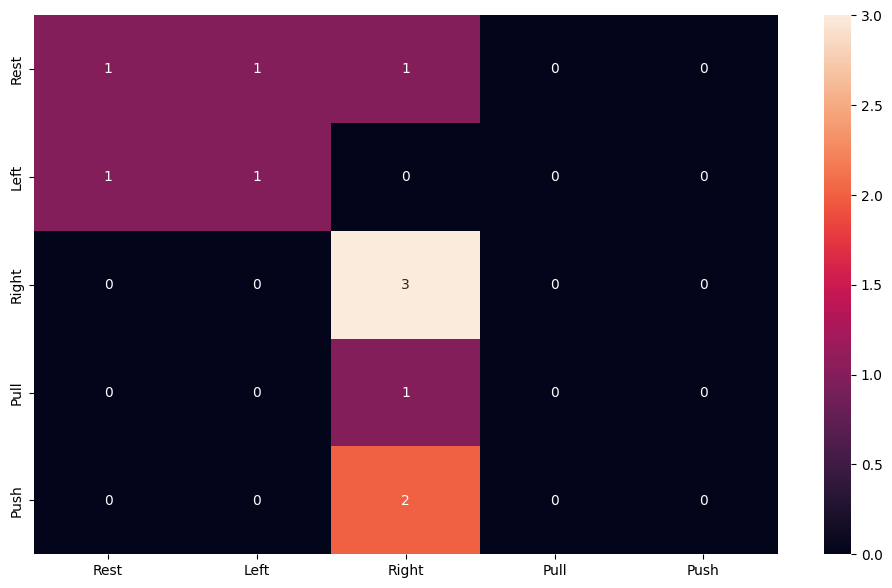

In [265]:
classes = ('Rest', 'Left', 'Right', 'Pull', 'Push')
# classes = ('Left', 'Right', 'Pull', 'Push')
# classes = ('Rest', 'Left')
# classes = ('Left', 'Right')
# classes = ('Pull', 'Push')

print(test_labels.numpy())
print((preds))



cf_matrix = confusion_matrix(test_labels.numpy(), preds)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sns.heatmap(df_cm, annot=True)
plt.savefig('output.png')

# TODO: LTSM

In [269]:
# Initialize the model, loss function, and optimizer
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


model = EEGNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

input = full_tensor

batch_size = 16
train_dataset = TensorDataset(training_input, training_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


num_epochs = 8
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        # inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    # if accuracy >= 75.:
    #     break

print("Training complete!")

Epoch [1/8], Loss: 4.0405, Accuracy: 12.00%
Epoch [2/8], Loss: 1.6419, Accuracy: 50.00%
Epoch [3/8], Loss: 1.3096, Accuracy: 66.00%
Epoch [4/8], Loss: 0.8128, Accuracy: 74.00%
Epoch [5/8], Loss: 0.6153, Accuracy: 86.00%
Epoch [6/8], Loss: 0.2927, Accuracy: 94.00%
Epoch [7/8], Loss: 0.1904, Accuracy: 94.00%
Epoch [8/8], Loss: 0.1716, Accuracy: 98.00%
Training complete!


In [270]:
correct = 0
total = len(test_labels)
preds = []
outs = []

model.eval()

for inputs, labels in zip(test_input, test_labels):
    # inputs, labels = inputs.to(device), labels.to(device)
    inputs = inputs.unsqueeze(0)

    output = model(inputs)
    _, predicted = torch.max(output, 1)  # Get predicted class
    correct += (predicted == labels).sum().item()
    preds.append(predicted)
    outs.append(output)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 27.27%


[4 0 2 1 3 4 0 2 1 0 2]
[tensor([4]), tensor([2]), tensor([3]), tensor([1]), tensor([2]), tensor([0]), tensor([2]), tensor([1]), tensor([0]), tensor([4]), tensor([2])]


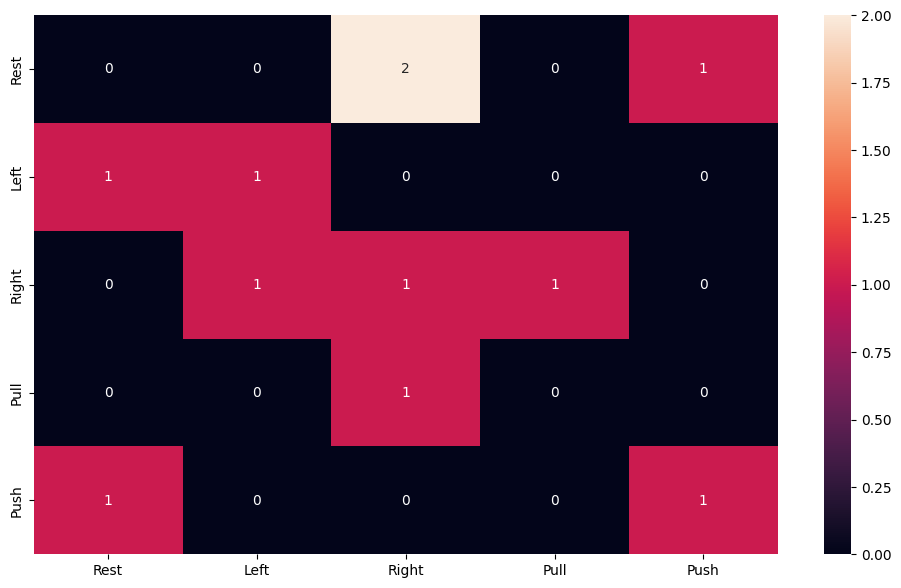

In [271]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt 


classes = ('Rest', 'Left', 'Right', 'Pull', 'Push')
# classes = ('Left', 'Right', 'Pull', 'Push')
# classes = ('Rest', 'Left')
# classes = ('Left', 'Right')
# classes = ('Pull', 'Push')


print(test_labels.numpy())
print((preds))



cf_matrix = confusion_matrix(test_labels.numpy(), preds)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')

# TODO: LTSM

In [282]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, layer_dim=5, output_dim=5):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        
        # Define LSTM
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        
        # Fully Connected Layer for classification
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        batch_size = x.size(0)  # Get the batch size from the input tensor
        
        # Initialize hidden & cell states if not provided (using current batch size)
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, batch_size, self.hidden_dim).to(x.device)

        # Forward propagate LSTM
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # Extract the output from the last timestep
        out = out[:, -1, :]  # shape: (batch_size, hidden_dim)
        
        # Fully connected layer (classification)
        out = self.fc(out)  # shape: (batch_size, output_dim)
        
        return out

In [283]:
model = LSTMModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

batch_size = 16
train_dataset = TensorDataset(training_input, training_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [284]:
num_epochs = 80
h0, c0 = None, None

model = LSTMModel()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        # inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs, h0, c0)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # h0 = h0.detach()
        # c0 = c0.detach()

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    if accuracy >= 75.:
        break

print("Training complete!")

Epoch [1/80], Loss: 1.6471, Accuracy: 14.00%
Epoch [2/80], Loss: 1.6529, Accuracy: 12.00%
Epoch [3/80], Loss: 1.6241, Accuracy: 22.00%
Epoch [4/80], Loss: 1.6060, Accuracy: 20.00%
Epoch [5/80], Loss: 1.6257, Accuracy: 22.00%
Epoch [6/80], Loss: 1.6016, Accuracy: 20.00%
Epoch [7/80], Loss: 1.6126, Accuracy: 20.00%
Epoch [8/80], Loss: 1.6276, Accuracy: 20.00%
Epoch [9/80], Loss: 1.5870, Accuracy: 30.00%
Epoch [10/80], Loss: 1.6946, Accuracy: 26.00%
Epoch [11/80], Loss: 1.6922, Accuracy: 14.00%
Epoch [12/80], Loss: 1.6284, Accuracy: 20.00%
Epoch [13/80], Loss: 1.6719, Accuracy: 16.00%
Epoch [14/80], Loss: 1.5975, Accuracy: 24.00%
Epoch [15/80], Loss: 1.5650, Accuracy: 26.00%
Epoch [16/80], Loss: 1.6813, Accuracy: 20.00%
Epoch [17/80], Loss: 1.5584, Accuracy: 30.00%
Epoch [18/80], Loss: 1.6355, Accuracy: 20.00%
Epoch [19/80], Loss: 1.6737, Accuracy: 22.00%
Epoch [20/80], Loss: 1.6971, Accuracy: 22.00%
Epoch [21/80], Loss: 1.6003, Accuracy: 22.00%
Epoch [22/80], Loss: 1.6124, Accuracy: 22.0

KeyboardInterrupt: 

In [279]:
correct = 0
total = len(test_labels)
preds = []
outs = []

model.eval()

for inputs, labels in zip(test_input, test_labels):
    # inputs, labels = inputs.to(device), labels.to(device)
    inputs = inputs.unsqueeze(0)

    output = model(inputs)
    _, predicted = torch.max(output, 1)  # Get predicted class
    correct += (predicted == labels).sum().item()
    preds.append(predicted)
    outs.append(output)

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 18.18%


[4 0 2 1 3 4 0 2 1 0 2]
[tensor([1]), tensor([3]), tensor([3]), tensor([3]), tensor([2]), tensor([3]), tensor([1]), tensor([3]), tensor([3]), tensor([0]), tensor([2])]


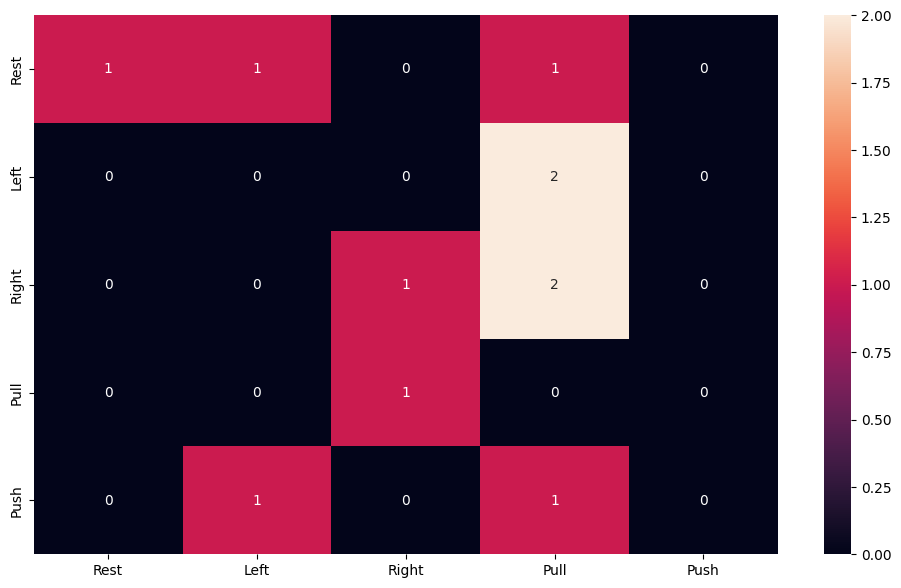

In [280]:
classes = ('Rest', 'Left', 'Right', 'Pull', 'Push')
# classes = ('Left', 'Right', 'Pull', 'Push')
# classes = ('Rest', 'Left')
# classes = ('Left', 'Right')
# classes = ('Pull', 'Push')


print(test_labels.numpy())
print((preds))



cf_matrix = confusion_matrix(test_labels.numpy(), preds)
df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes],
                     columns = [i for i in classes])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)
plt.savefig('output.png')

# TODO: LTSM